# 🚀 GoViralIQ
## Notebook 3: Data Visualization
**Project:** Predicting Instagram Engagement & Auditing Algorithmic Fairness Across Creator Niches  
**Author:** Chastity Lewis  
**Course:** CISC 540 — Computational Data Analysis | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
In this notebook we will:
1. Visualize engagement rate distributions
2. Compare engagement across content types
3. Analyze regional engagement patterns
4. Build a correlation heatmap
5. Explore viral vs non-viral post characteristics
6. Lay the visual foundation for the fairness audit

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# GoViralIQ color palette
plt.style.use('seaborn-v0_8-whitegrid')
PURPLE      = '#6B21A8'
LIGHT_PURPLE = '#D8B4FE'
DARK        = '#1F1F1F'
SOFT        = '#F3E8FF'
MID_PURPLE  = '#9333EA'
COLORS      = [PURPLE, LIGHT_PURPLE, MID_PURPLE, '#A855F7', '#7C3AED']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load the Clean Dataset from Notebook 2

In [10]:
from google.colab import files
import pandas as pd
import io

# Upload your goviraliq_instagram_clean.csv file
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Loaded: {filename}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')

Saving goviraliq_instagram_raw.csv to goviraliq_instagram_raw.csv
✅ Loaded: goviraliq_instagram_raw.csv
📊 Shape: 1,212 rows × 12 columns

Columns: ['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level', 'engagement_rate', 'viral']


## Step 3: Engagement Rate Distribution

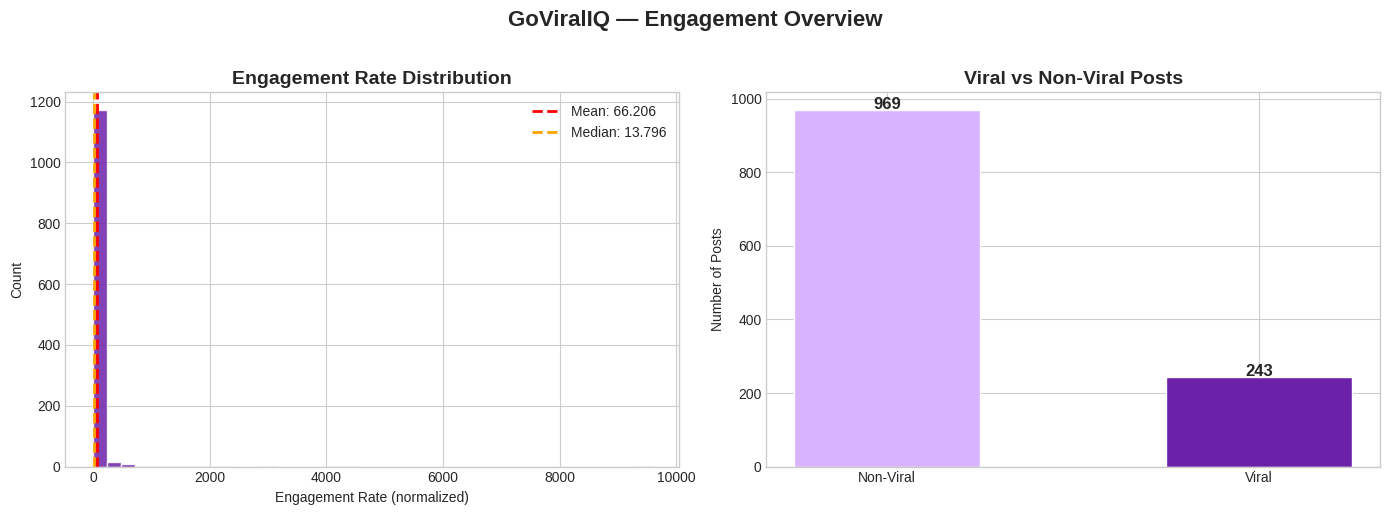

✅ Saved viz_01_engagement_overview.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['engagement_rate'], bins=40, color=PURPLE, edgecolor='white', alpha=0.85)
axes[0].set_title('Engagement Rate Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Engagement Rate (normalized)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['engagement_rate'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["engagement_rate"].mean():.3f}')
axes[0].axvline(df['engagement_rate'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["engagement_rate"].median():.3f}')
axes[0].legend()

# Viral vs Non-Viral
viral_counts = df['viral'].value_counts()
bars = axes[1].bar(['Non-Viral', 'Viral'], viral_counts.sort_index().values,
                   color=[LIGHT_PURPLE, PURPLE], edgecolor='white', width=0.5)
for bar, count in zip(bars, viral_counts.sort_index().values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{count:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Viral vs Non-Viral Posts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Posts')

plt.suptitle('GoViralIQ — Engagement Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_engagement_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_01_engagement_overview.png')

## Step 4: Engagement by Content Type

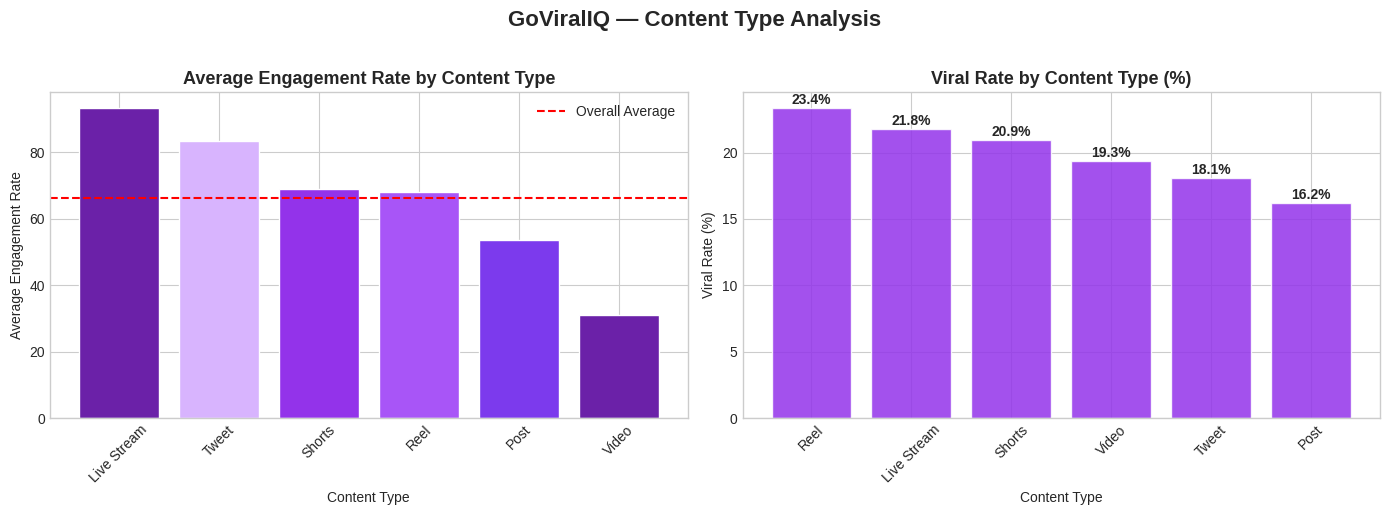

✅ Saved viz_02_content_type.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average engagement by content type
content_eng = df.groupby('Content_Type')['engagement_rate'].mean().sort_values(ascending=False)
bars = axes[0].bar(content_eng.index, content_eng.values, color=COLORS[:len(content_eng)], edgecolor='white')
axes[0].set_title('Average Engagement Rate by Content Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Content Type')
axes[0].set_ylabel('Average Engagement Rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(df['engagement_rate'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall Average')
axes[0].legend()

# Viral rate by content type
viral_by_content = df.groupby('Content_Type')['viral'].mean() * 100
viral_by_content = viral_by_content.sort_values(ascending=False)
bars2 = axes[1].bar(viral_by_content.index, viral_by_content.values, color=MID_PURPLE, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, viral_by_content.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Viral Rate by Content Type (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('Viral Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('GoViralIQ — Content Type Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_content_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_02_content_type.png')

## Step 5: Regional Engagement Analysis

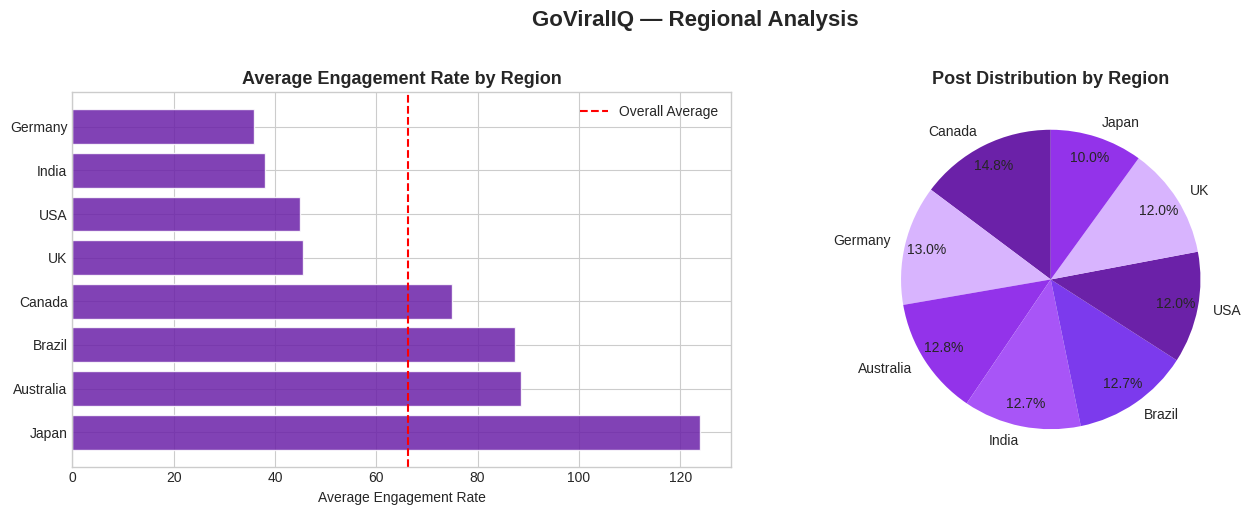

✅ Saved viz_03_regional.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average engagement by region
region_eng = df.groupby('Region')['engagement_rate'].mean().sort_values(ascending=False)
axes[0].barh(region_eng.index, region_eng.values, color=PURPLE, edgecolor='white', alpha=0.85)
axes[0].set_title('Average Engagement Rate by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Engagement Rate')
axes[0].axvline(df['engagement_rate'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall Average')
axes[0].legend()

# Post count by region
region_count = df['Region'].value_counts()
axes[1].pie(region_count.values, labels=region_count.index, autopct='%1.1f%%',
            colors=COLORS * (len(region_count) // len(COLORS) + 1),
            startangle=90, pctdistance=0.85)
axes[1].set_title('Post Distribution by Region', fontsize=13, fontweight='bold')

plt.suptitle('GoViralIQ — Regional Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_03_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_03_regional.png')

## Step 6: Correlation Heatmap

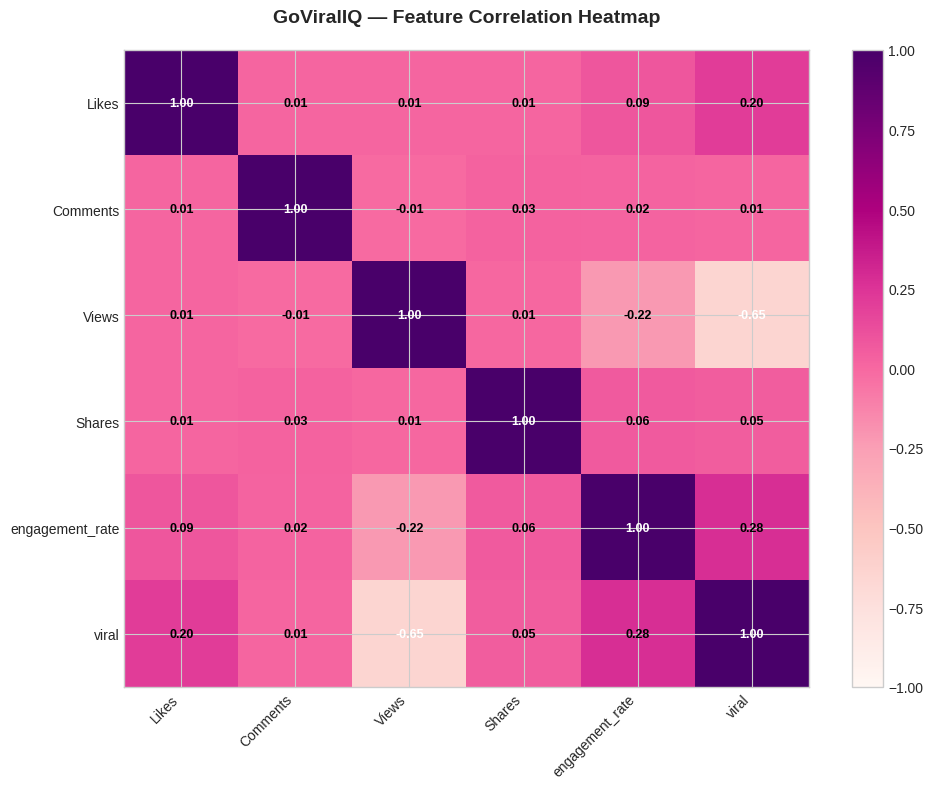

✅ Saved viz_04_correlation_heatmap.png

🔍 Key correlations with engagement_rate:
engagement_rate    1.000000
viral              0.275024
Likes              0.085818
Shares             0.063047
Comments           0.017469
Views             -0.222826
Name: engagement_rate, dtype: float64


In [14]:
# Select numeric columns for correlation
numeric_cols = ['Likes', 'Comments', 'Views', 'Shares', 'engagement_rate',
                'viral', 'hashtag_length', 'is_video', 'engagement_level_num']

# Only use columns that exist in the dataframe
numeric_cols = [col for col in numeric_cols if col in df.columns]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap manually with Matplotlib
im = ax.imshow(corr_matrix, cmap='RdPu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_matrix.index, fontsize=10)
ax.set_title('GoViralIQ — Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('viz_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_04_correlation_heatmap.png')
print('\n🔍 Key correlations with engagement_rate:')
print(corr_matrix['engagement_rate'].sort_values(ascending=False))

## Step 7: Viral vs Non-Viral Feature Comparison

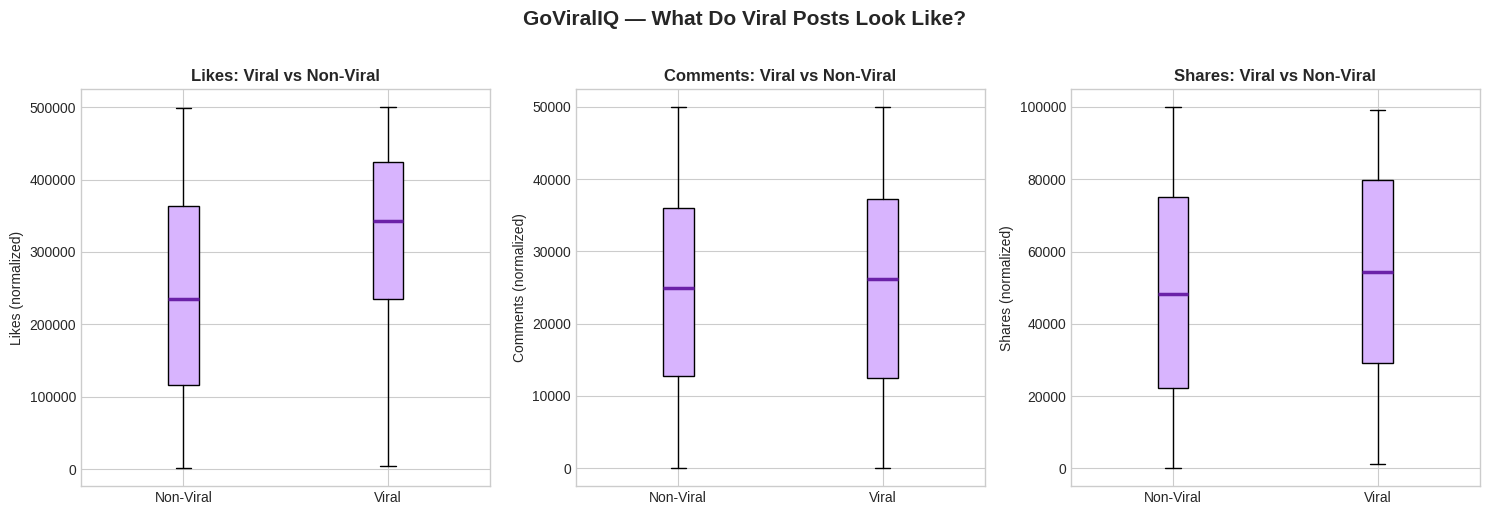

✅ Saved viz_05_viral_comparison.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features = ['Likes', 'Comments', 'Shares']
for ax, feature in zip(axes, features):
    viral_data = df[df['viral'] == 1][feature]
    non_viral_data = df[df['viral'] == 0][feature]
    ax.boxplot([non_viral_data, viral_data], patch_artist=True,
               labels=['Non-Viral', 'Viral'],
               boxprops=dict(facecolor=LIGHT_PURPLE),
               medianprops=dict(color=PURPLE, linewidth=2.5))
    ax.set_title(f'{feature}: Viral vs Non-Viral', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{feature} (normalized)')

plt.suptitle('GoViralIQ — What Do Viral Posts Look Like?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_05_viral_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_05_viral_comparison.png')

## Step 8: Fairness Foundation — Viral Rate by Content Type & Region

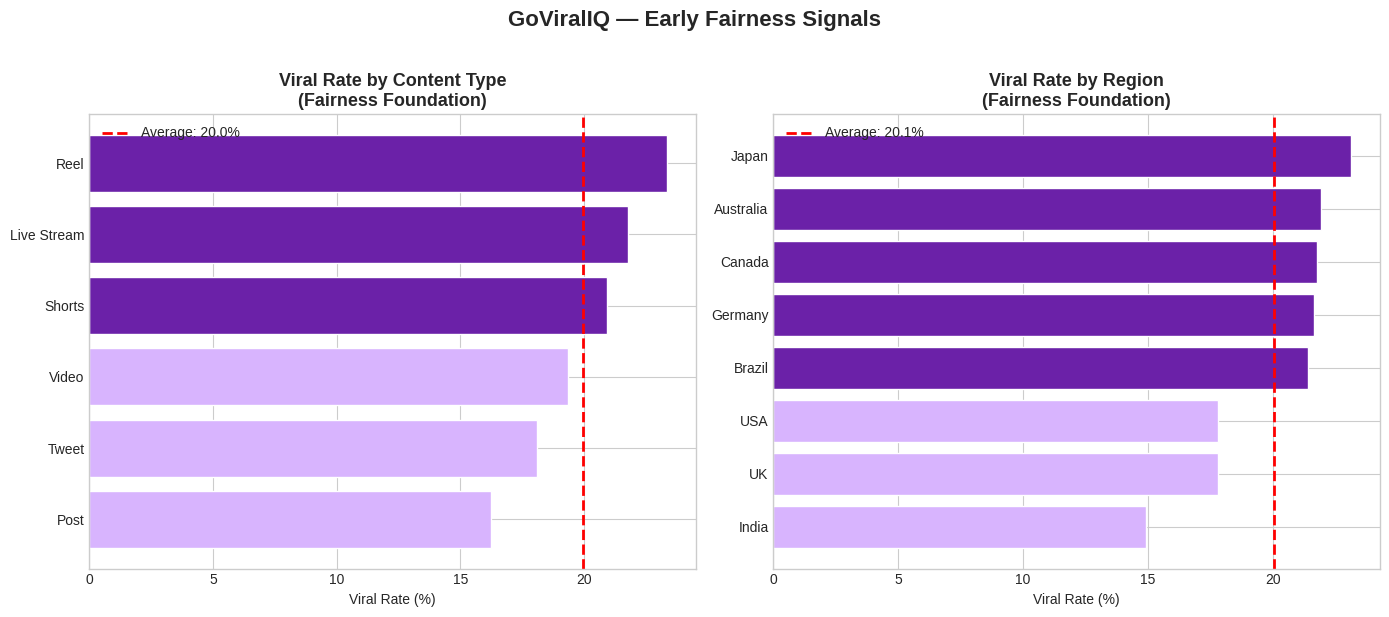

✅ Saved viz_06_fairness_foundation.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Viral rate by content type — fairness preview
fairness_content = df.groupby('Content_Type').agg(
    viral_rate=('viral', 'mean'),
    post_count=('viral', 'count')
).reset_index()
fairness_content['viral_rate_pct'] = fairness_content['viral_rate'] * 100
fairness_content = fairness_content.sort_values('viral_rate_pct', ascending=True)

colors_bar = [PURPLE if v > fairness_content['viral_rate_pct'].mean() else LIGHT_PURPLE
              for v in fairness_content['viral_rate_pct']]
axes[0].barh(fairness_content['Content_Type'], fairness_content['viral_rate_pct'],
             color=colors_bar, edgecolor='white')
axes[0].axvline(fairness_content['viral_rate_pct'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Average: {fairness_content["viral_rate_pct"].mean():.1f}%')
axes[0].set_title('Viral Rate by Content Type\n(Fairness Foundation)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Viral Rate (%)')
axes[0].legend()

# Viral rate by region — fairness preview
fairness_region = df.groupby('Region').agg(
    viral_rate=('viral', 'mean'),
    post_count=('viral', 'count')
).reset_index()
fairness_region['viral_rate_pct'] = fairness_region['viral_rate'] * 100
fairness_region = fairness_region.sort_values('viral_rate_pct', ascending=True)

colors_bar2 = [PURPLE if v > fairness_region['viral_rate_pct'].mean() else LIGHT_PURPLE
               for v in fairness_region['viral_rate_pct']]
axes[1].barh(fairness_region['Region'], fairness_region['viral_rate_pct'],
             color=colors_bar2, edgecolor='white')
axes[1].axvline(fairness_region['viral_rate_pct'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Average: {fairness_region["viral_rate_pct"].mean():.1f}%')
axes[1].set_title('Viral Rate by Region\n(Fairness Foundation)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Viral Rate (%)')
axes[1].legend()

plt.suptitle('GoViralIQ — Early Fairness Signals', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_06_fairness_foundation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_06_fairness_foundation.png')

## Step 9: Engagement Level Distribution

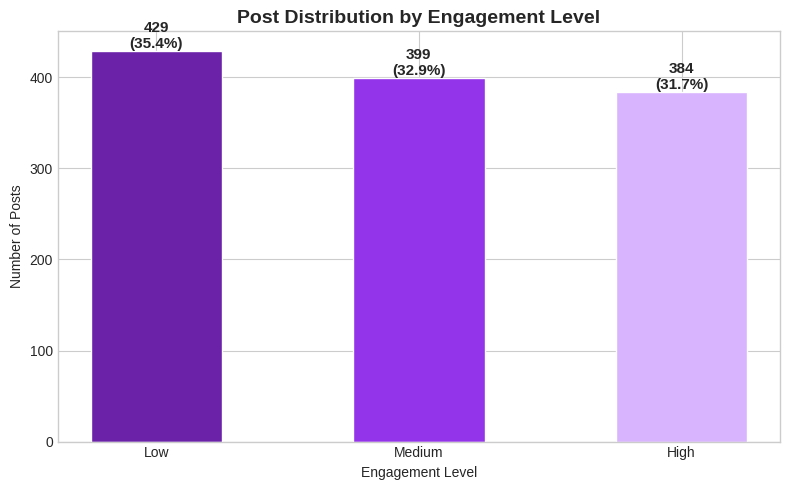

✅ Saved viz_07_engagement_levels.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

eng_counts = df['Engagement_Level'].value_counts()
bars = ax.bar(eng_counts.index, eng_counts.values,
              color=[PURPLE, MID_PURPLE, LIGHT_PURPLE], edgecolor='white', width=0.5)

for bar, count in zip(bars, eng_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Post Distribution by Engagement Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Engagement Level')
ax.set_ylabel('Number of Posts')

plt.tight_layout()
plt.savefig('viz_07_engagement_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved viz_07_engagement_levels.png')

## Step 10: Visualization Summary

In [18]:
print('=' * 55)
print('       GoViralIQ — Notebook 3 Summary')
print('=' * 55)
print('\n📊 Charts created:')
print('   viz_01_engagement_overview.png')
print('   viz_02_content_type.png')
print('   viz_03_regional.png')
print('   viz_04_correlation_heatmap.png')
print('   viz_05_viral_comparison.png')
print('   viz_06_fairness_foundation.png')
print('   viz_07_engagement_levels.png')
print(f'\n🔍 Key Findings:')
top_content = df.groupby('Content_Type')['engagement_rate'].mean().idxmax()
top_region = df.groupby('Region')['engagement_rate'].mean().idxmax()
top_corr = df[numeric_cols].corr()['engagement_rate'].drop('engagement_rate').abs().idxmax()
print(f'   Highest engaging content type: {top_content}')
print(f'   Highest engaging region: {top_region}')
print(f'   Strongest feature correlated with engagement: {top_corr}')
print('\n' + '=' * 55)
print('\n✅ Next: Notebook 04 — Machine Learning Models')

       GoViralIQ — Notebook 3 Summary

📊 Charts created:
   viz_01_engagement_overview.png
   viz_02_content_type.png
   viz_03_regional.png
   viz_04_correlation_heatmap.png
   viz_05_viral_comparison.png
   viz_06_fairness_foundation.png
   viz_07_engagement_levels.png

🔍 Key Findings:
   Highest engaging content type: Live Stream
   Highest engaging region: Japan
   Strongest feature correlated with engagement: viral


✅ Next: Notebook 04 — Machine Learning Models
